# Random Forest

### NOTE:
**All the code has been designed to be executed on an NVIDIA GPU with CUDA version 12.5**

In [1]:
# %conda install numpy scikit-learn matplotlib

In [2]:
import warnings
import json
import numpy as np
import pandas as pd
from sklearn import metrics
import cuml.metrics as cl_metrics
import matplotlib.pyplot as plt
from typing import Iterable

import cudf

warnings.filterwarnings('ignore')

DATA_PATH = './../data_numpy'
BEST_PARAMS_PATH = './../best_params/RF' 

In [3]:
Xtr = pd.read_csv(f'./{DATA_PATH}/Xtr_encoded.csv')
Xval = pd.read_csv(f'./{DATA_PATH}/Xval_encoded.csv')
Xte = pd.read_csv(f'./{DATA_PATH}/Xte_encoded.csv')
ytr = pd.read_csv(f'./{DATA_PATH}/ytr.csv')
yval = pd.read_csv(f'./{DATA_PATH}/yval.csv')
yte = pd.read_csv(f'./{DATA_PATH}/yte.csv')


Xtr_oversampled = pd.read_csv(f'./{DATA_PATH}/Xtr_resampled_encoded.csv')
Xval_oversampled = pd.read_csv(f'./{DATA_PATH}/Xval_resampled_encoded.csv')
Xte_oversampled = pd.read_csv(f'./{DATA_PATH}/Xte_resampled_encoded.csv')
ytr_oversampled = pd.read_csv(f'./{DATA_PATH}/ytr_resampled_encoded.csv')
yval_oversampled = pd.read_csv(f'./{DATA_PATH}/yval_resampled_encoded.csv')
yte_oversampled = pd.read_csv(f'./{DATA_PATH}/yte_resampled_encoded.csv')

# Load the datasets in the GPU
Xtr = cudf.DataFrame(Xtr)
Xval = cudf.DataFrame(Xtr)
Xte = cudf.DataFrame(Xte)
ytr = cudf.Series(ytr.values.flatten())
yval = cudf.Series(yval.values.flatten())
yte = cudf.Series(yte.values.flatten())

Xtr_oversampled = cudf.DataFrame(Xtr_oversampled)
Xval_oversampled = cudf.DataFrame(Xval_oversampled)
Xte_oversampled = cudf.DataFrame(Xte_oversampled)
ytr_oversampled = cudf.Series(ytr_oversampled.values.flatten())
yval_oversampled = cudf.Series(yval_oversampled.values.flatten())
yte_oversampled = cudf.Series(yte_oversampled.values.flatten())

# Cross Validation

estimated completion time: $\approx 1$ hour 

In [4]:
from functools import reduce
from operator import mul
import time
from cuml.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterGrid


def CV(
        Xtr: pd.DataFrame, ytr: pd.Series,
        Xval: pd.DataFrame, yval: pd.Series,
        n_estimators: Iterable,
        max_depth: Iterable,
        min_samples_split: Iterable,
        min_samples_leaf: Iterable,
        max_features: Iterable,
        random_state=1
):
    best_score = -1
    best_params = None

    param_grid = {
        'n_estimators': n_estimators,
        'max_depth': max_depth,
        'min_samples_split': min_samples_split,
        'min_samples_leaf': min_samples_leaf,
        'max_features': max_features,
        'split_criterion': ['gini', 'entropy']
    }

    fits = reduce(mul, [len(param) for param in param_grid.values()])
    i = 1

    for params in ParameterGrid(param_grid):
        timer = time.time()

        model = RandomForestClassifier(
            **params, random_state=random_state)
        model.fit(Xtr, ytr)

        # probabilities for class 1
        y_pred = model.predict_proba(Xval)[1]
        score = cl_metrics.roc_auc_score(yval, y_pred)

        end = time.time() - timer
        elapsed_time = f"{end:.1f}s" if end < 60 else f"{(end / 60):.1f}min"
        print(
            f"[fit {i}/{fits}] score = {score:.6f} total time = {elapsed_time}")
        i += 1

        if score > best_score:
            best_score = score
            best_params = params

    return best_params, best_score

In [6]:
param_grid = {
    "n_estimators": [10, 50, 100, 200, 300],
    "max_depth": [3, 5, 8, 10, 16],
    "min_samples_split": [2, 5, 10, 12, 14],
    "min_samples_leaf":  [1, 2, 4, 6, 8, 10],
    "max_features": ['sqrt', 'log2']
}


choice = input("Do you want to execute this cell? (yes/no): ")
if choice.lower() == "yes":
    print("Executing cross validation...")
    best_params, best_score = CV(
        Xtr, ytr, Xval, yval, **param_grid)
    with open(f"{BEST_PARAMS_PATH}/best_params.json", "w") as f:
        json.dump(best_params, f)
else:
    print("Loading data locally...")
    with open(f"{BEST_PARAMS_PATH}/best_params.json", "r") as f:
        best_params = json.load(f)

print(f"\nBest params:")
print(json.dumps(best_params, indent=2))
print(f"Best score: {best_score:.3f}")

Executing cross validation...
[fit 1/3000] score=0.831649 total time=   3.2s
[fit 2/3000] score=0.833377 total time=   0.3s
[fit 3/3000] score=0.834719 total time=   1.3s
[fit 4/3000] score=0.838107 total time=   1.1s
[fit 5/3000] score=0.835856 total time=   2.4s
[fit 6/3000] score=0.839489 total time=   2.3s
[fit 7/3000] score=0.836859 total time=   4.5s
[fit 8/3000] score=0.840743 total time=   4.3s
[fit 9/3000] score=0.837344 total time=   6.8s
[fit 10/3000] score=0.841439 total time=   6.6s
[fit 11/3000] score=0.831649 total time=   0.3s
[fit 12/3000] score=0.833377 total time=   0.3s
[fit 13/3000] score=0.834719 total time=   1.2s
[fit 14/3000] score=0.838107 total time=   1.2s
[fit 15/3000] score=0.835856 total time=   2.4s
[fit 16/3000] score=0.839489 total time=   2.3s
[fit 17/3000] score=0.836859 total time=   4.4s
[fit 18/3000] score=0.840743 total time=   4.3s
[fit 19/3000] score=0.837344 total time=   6.9s
[fit 20/3000] score=0.841439 total time=   6.6s
[fit 21/3000] score

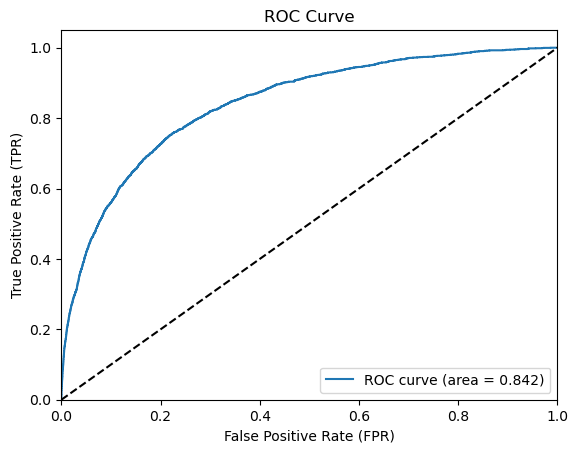

In [ ]:
model = RandomForestClassifier(**best_params, random_state=1)
model.fit(Xtr, ytr)
y_pred = model.predict_proba(Xte)[1]  # probabilities for class 1
fpr, tpr, _ = metrics.roc_curve(yte.to_numpy(), y_pred.to_numpy())
roc_auc = metrics.auc(fpr, tpr)

# ROC
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')  # bisector
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

## Oversampled datasets

In [5]:
param_grid = {
    "n_estimators": [10, 50, 100, 200, 300],
    "max_depth": [3, 5, 8, 10, 16],
    "min_samples_split": [2, 5, 10, 12, 14],
    "min_samples_leaf":  [1, 2, 4, 6, 8, 10],
    "max_features": ['sqrt', 'log2']
}


choice = input("Do you want to execute this cell? (yes/no): ")
if choice.lower() == "yes":
    print("Executing cross validation...")
    best_params, best_score = CV(
        Xtr_oversampled, ytr_oversampled, Xval_oversampled, yval_oversampled, **param_grid)
    with open(f"{BEST_PARAMS_PATH}/../oversampling/RF/best_params.json", "w") as f:
        json.dump(best_params, f)
else:
    print("Loading data locally...")
    with open(f"{BEST_PARAMS_PATH}/../oversampling/RF/best_params.json", "r") as f:
        best_params = json.load(f)

print(f"\nBest params:")
print(json.dumps(best_params, indent=2))
print(f"Best score: {best_score:.3f}")

Executing cross validation...
[fit 1/3000] score = 0.871835 total time = 1.0s
[fit 2/3000] score = 0.875586 total time = 0.5s
[fit 3/3000] score = 0.884232 total time = 1.9s
[fit 4/3000] score = 0.886222 total time = 1.9s
[fit 5/3000] score = 0.883205 total time = 3.7s
[fit 6/3000] score = 0.886235 total time = 3.8s
[fit 7/3000] score = 0.888750 total time = 7.2s
[fit 8/3000] score = 0.892433 total time = 7.3s
[fit 9/3000] score = 0.888222 total time = 11.0s
[fit 10/3000] score = 0.891155 total time = 11.1s
[fit 11/3000] score = 0.871835 total time = 0.4s
[fit 12/3000] score = 0.875586 total time = 0.4s
[fit 13/3000] score = 0.884232 total time = 1.9s
[fit 14/3000] score = 0.886222 total time = 1.8s
[fit 15/3000] score = 0.883205 total time = 3.7s
[fit 16/3000] score = 0.886235 total time = 3.8s
[fit 17/3000] score = 0.888750 total time = 7.4s
[fit 18/3000] score = 0.892433 total time = 7.3s
[fit 19/3000] score = 0.888222 total time = 10.9s
[fit 20/3000] score = 0.891155 total time = 1

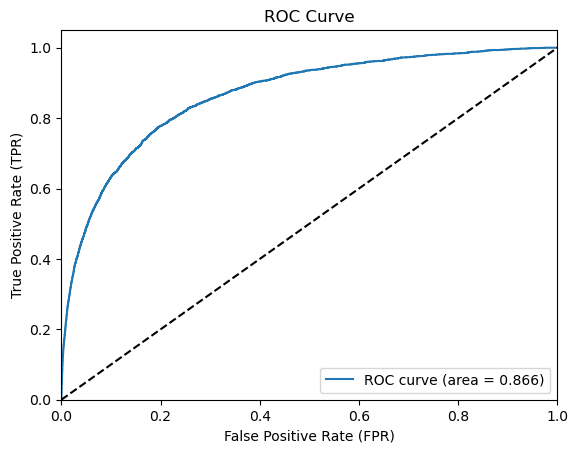

In [6]:
model = RandomForestClassifier(**best_params, random_state=1)
model.fit(Xtr, ytr)
y_pred = model.predict_proba(Xte)[1]  # probabilities for class 1
fpr, tpr, _ = metrics.roc_curve(yte.to_numpy(), y_pred.to_numpy())
roc_auc = metrics.auc(fpr, tpr)

# ROC
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')  # bisector
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()